In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [3]:
df =pd.read_csv("loan_approval_data1.csv")

In [4]:
df

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,LP000001,48900,0,Employed,26,Divorced,2,644,2,0.381,11100,0,90000,360,Business,Urban,Postgraduate,Male,Government,N
1,LP000002,33400,0,Employed,52,Married,1,582,1,0.316,4400,147600,123000,360,Home Improvement,Urban,Postgraduate,Male,Private Sector,N
2,LP000003,53600,21200,Self-Employed,61,Married,3,503,1,0.399,6500,0,172000,180,Education,Urban,Graduate,Male,Government,N
3,LP000004,90600,35300,Employed,63,Married,0,661,0,0.455,14600,598800,499000,240,Home Purchase,Rural,High School,Male,Private Sector,N
4,LP000005,31600,0,Employed,59,Single,0,690,3,0.426,16100,170400,142000,180,Home Purchase,Rural,Postgraduate,Male,Private Sector,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,LP000996,30700,0,Employed,51,Married,1,748,0,0.391,11500,84000,105000,360,Home Purchase,Semiurban,Postgraduate,Male,Private Sector,Y
996,LP000997,106800,0,Employed,43,Married,0,725,0,0.384,8500,340800,284000,120,Debt Consolidation,Semiurban,Graduate,Male,Self-Employed,Y
997,LP000998,53300,10700,Employed,40,Single,0,766,1,0.490,38500,0,271000,240,Business,Rural,Graduate,Male,MNC,Y
998,LP000999,25800,0,Employed,35,Married,2,706,0,0.353,5600,171000,114000,240,Home Purchase,Semiurban,Graduate,Female,MNC,Y


In [5]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   str    
 1   Applicant_Income    1000 non-null   int64  
 2   Coapplicant_Income  1000 non-null   int64  
 3   Employment_Status   1000 non-null   str    
 4   Age                 1000 non-null   int64  
 5   Marital_Status      1000 non-null   str    
 6   Dependents          1000 non-null   int64  
 7   Credit_Score        1000 non-null   int64  
 8   Existing_Loans      1000 non-null   int64  
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   int64  
 11  Collateral_Value    1000 non-null   int64  
 12  Loan_Amount         1000 non-null   int64  
 13  Loan_Term           1000 non-null   int64  
 14  Loan_Purpose        1000 non-null   str    
 15  Property_Area       1000 non-null   str    
 16  Education_Level   

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03,1000.000000
mean,43842.300000,11857.900000,42.338000,1.055000,675.284000,1.030000,0.323007,20340.200000,1.527448e+05,1.678990e+05,262.680000
std,29631.019524,13096.697334,12.533429,1.032008,80.471666,0.973678,0.102601,17360.416124,1.715228e+05,1.226797e+05,85.342257
min,5200.000000,0.000000,21.000000,0.000000,448.000000,0.000000,0.050000,1700.000000,0.000000e+00,1.800000e+04,120.000000
25%,24600.000000,0.000000,32.000000,0.000000,619.750000,0.000000,0.253750,9000.000000,0.000000e+00,8.975000e+04,180.000000
50%,36900.000000,10750.000000,42.000000,1.000000,675.000000,1.000000,0.320500,15300.000000,1.244000e+05,1.380000e+05,240.000000
75%,53600.000000,20300.000000,53.000000,2.000000,733.000000,2.000000,0.394000,25200.000000,2.197000e+05,2.100000e+05,360.000000
max,366500.000000,85400.000000,64.000000,3.000000,850.000000,4.000000,0.650000,200500.000000,1.939200e+06,1.616000e+06,360.000000


In [6]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['str']).columns

# categorical_cols = df.select_dtypes(include=["float64"]).columns
# numerical_cols = df.select_dtypes(include=["number"]).columns

In [7]:































# categorical_cols.size + numerical_cols.size

In [8]:
categorical_cols

Index(['Applicant_ID', 'Employment_Status', 'Marital_Status', 'Loan_Purpose',
       'Property_Area', 'Education_Level', 'Gender', 'Employer_Category',
       'Loan_Approved'],
      dtype='str')

In [9]:
numerical_cols

Index(['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='str')

In [10]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

In [11]:
cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

In [12]:
# df.head()
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

In [13]:
print(categorical_cols)

Index(['Applicant_ID', 'Employment_Status', 'Marital_Status', 'Loan_Purpose',
       'Property_Area', 'Education_Level', 'Gender', 'Employer_Category',
       'Loan_Approved'],
      dtype='str')


In [14]:
# EDA

df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,LP000001,48900.0,0.0,Employed,26.0,Divorced,2.0,644.0,2.0,0.381,11100.0,0.0,90000.0,360.0,Business,Urban,Postgraduate,Male,Government,N
1,LP000002,33400.0,0.0,Employed,52.0,Married,1.0,582.0,1.0,0.316,4400.0,147600.0,123000.0,360.0,Home Improvement,Urban,Postgraduate,Male,Private Sector,N
2,LP000003,53600.0,21200.0,Self-Employed,61.0,Married,3.0,503.0,1.0,0.399,6500.0,0.0,172000.0,180.0,Education,Urban,Graduate,Male,Government,N
3,LP000004,90600.0,35300.0,Employed,63.0,Married,0.0,661.0,0.0,0.455,14600.0,598800.0,499000.0,240.0,Home Purchase,Rural,High School,Male,Private Sector,N
4,LP000005,31600.0,0.0,Employed,59.0,Single,0.0,690.0,3.0,0.426,16100.0,170400.0,142000.0,180.0,Home Purchase,Rural,Postgraduate,Male,Private Sector,Y


# EDA

Text(0.5, 1.0, 'Is lone approved or not!')

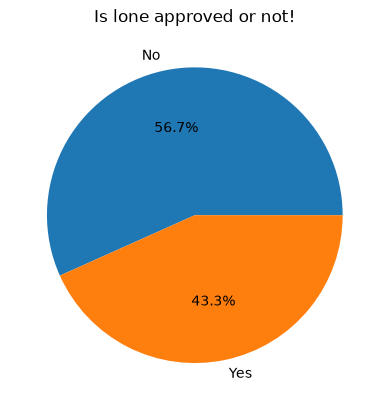

In [15]:
# how balance are classes are
classes_count = df["Loan_Approved"].value_counts()
plt.pie(classes_count,labels=["No","Yes"],autopct="%1.1f%%")
plt.title("Is lone approved or not!")

[Text(0, 0, '557'), Text(0, 0, '443')]

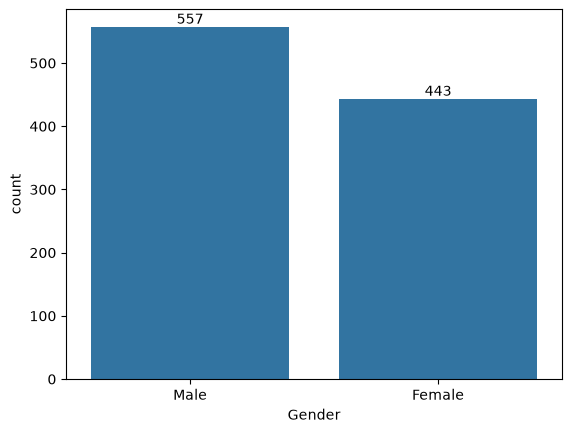

In [16]:
# Analyesed catagorey
gender_cns = df["Gender"].value_counts()
ax = sns.barplot(gender_cns)
ax.bar_label(ax.containers[0])

[Text(0, 0, '541'), Text(0, 0, '298'), Text(0, 0, '129'), Text(0, 0, '32')]

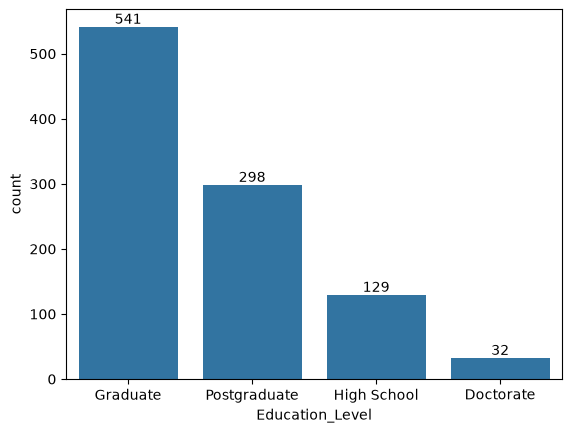

In [17]:
# education 
education_cns = df["Education_Level"].value_counts()
ax = sns.barplot(education_cns)
ax.bar_label(ax.containers[0])


<Axes: xlabel='Applicant_Income', ylabel='Count'>

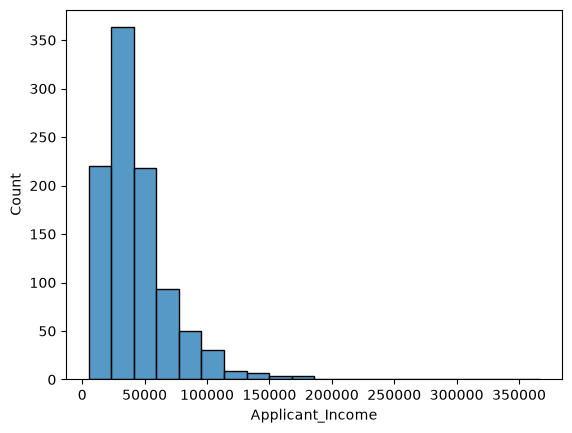

In [18]:
sns.histplot(
    data=df,
    x = "Applicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

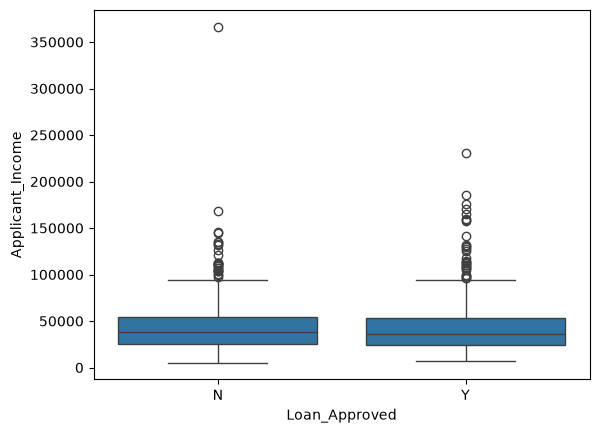

In [19]:
# outliers - boxplot

sns.boxplot(
    data = df,
    x="Loan_Approved",
    y="Applicant_Income"
)

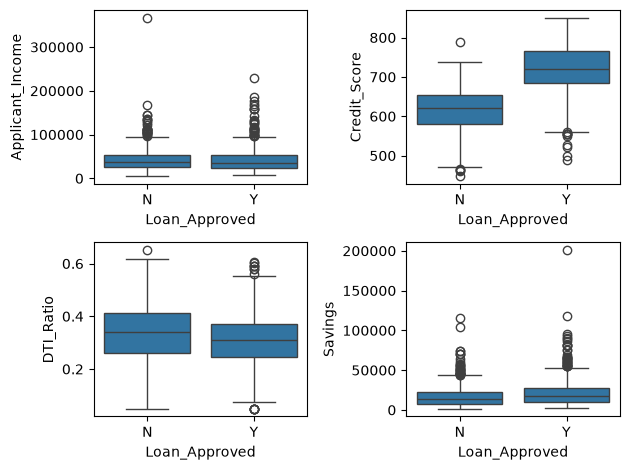

In [20]:
fig,axes = plt.subplots(2,2)

sns.boxplot(ax=axes[0,0],data = df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data = df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1,0],data = df,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,1],data = df,x="Loan_Approved",y="Savings")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

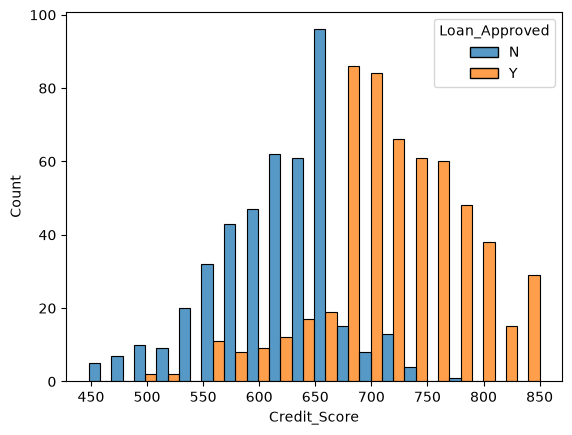

In [21]:
# credit score with lone approvale
sns.histplot(
    data=df,
    x= "Credit_Score",
    hue = "Loan_Approved",
    bins =20,
    multiple="dodge"

)
    

In [22]:
df = df.drop("Applicant_ID",axis=1)

In [23]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,48900.0,0.0,Employed,26.0,Divorced,2.0,644.0,2.0,0.381,11100.0,0.0,90000.0,360.0,Business,Urban,Postgraduate,Male,Government,N
1,33400.0,0.0,Employed,52.0,Married,1.0,582.0,1.0,0.316,4400.0,147600.0,123000.0,360.0,Home Improvement,Urban,Postgraduate,Male,Private Sector,N
2,53600.0,21200.0,Self-Employed,61.0,Married,3.0,503.0,1.0,0.399,6500.0,0.0,172000.0,180.0,Education,Urban,Graduate,Male,Government,N
3,90600.0,35300.0,Employed,63.0,Married,0.0,661.0,0.0,0.455,14600.0,598800.0,499000.0,240.0,Home Purchase,Rural,High School,Male,Private Sector,N
4,31600.0,0.0,Employed,59.0,Single,0.0,690.0,3.0,0.426,16100.0,170400.0,142000.0,180.0,Home Purchase,Rural,Postgraduate,Male,Private Sector,Y


# Encoding

In [24]:
# df.head()
# df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   str    
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   str    
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   str    
 14  Property_Area       1000 non-null   str    
 15  Education_Level     1000 non-null   str    
 16  Gender            

In [25]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

# cols = ["Employment_Status"," Marital_Status ","Loan_Purpose","Property_Area"," Gender","Employer_Category"]

In [26]:




df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,48900.0,0.0,Employed,26.0,Divorced,2.0,644.0,2.0,0.381,11100.0,0.0,90000.0,360.0,Business,Urban,3,Male,Government,0
1,33400.0,0.0,Employed,52.0,Married,1.0,582.0,1.0,0.316,4400.0,147600.0,123000.0,360.0,Home Improvement,Urban,3,Male,Private Sector,0
2,53600.0,21200.0,Self-Employed,61.0,Married,3.0,503.0,1.0,0.399,6500.0,0.0,172000.0,180.0,Education,Urban,1,Male,Government,0
3,90600.0,35300.0,Employed,63.0,Married,0.0,661.0,0.0,0.455,14600.0,598800.0,499000.0,240.0,Home Purchase,Rural,2,Male,Private Sector,0
4,31600.0,0.0,Employed,59.0,Single,0.0,690.0,3.0,0.426,16100.0,170400.0,142000.0,180.0,Home Purchase,Rural,3,Male,Private Sector,1


In [27]:
cols = ["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]
ohe = OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded = ohe.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=df.index)
df = pd.concat([df.drop(columns=cols),encoded_df],axis=1)

In [28]:
encoded_df.head()

,Employment_Status_Contract,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed,Marital_Status_Married,Marital_Status_Single,Loan_Purpose_Debt Consolidation,Loan_Purpose_Education,Loan_Purpose_Home Improvement,Loan_Purpose_Home Purchase,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_MNC,Employer_Category_PSU,Employer_Category_Private Sector,Employer_Category_Self-Employed
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [29]:
encoded_df

,Employment_Status_Contract,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed,Marital_Status_Married,Marital_Status_Single,Loan_Purpose_Debt Consolidation,Loan_Purpose_Education,Loan_Purpose_Home Improvement,Loan_Purpose_Home Purchase,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_MNC,Employer_Category_PSU,Employer_Category_Private Sector,Employer_Category_Self-Employed
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
996,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
997,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
998,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [30]:
ohe.get_feature_names_out(cols)

array(['Employment_Status_Contract', 'Employment_Status_Employed',
       'Employment_Status_Self-Employed', 'Employment_Status_Unemployed',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Loan_Purpose_Debt Consolidation', 'Loan_Purpose_Education',
       'Loan_Purpose_Home Improvement', 'Loan_Purpose_Home Purchase',
       'Loan_Purpose_Personal', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Gender_Male', 'Employer_Category_MNC',
       'Employer_Category_PSU', 'Employer_Category_Private Sector',
       'Employer_Category_Self-Employed'], dtype=object)

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 31 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Applicant_Income                  1000 non-null   float64
 1   Coapplicant_Income                1000 non-null   float64
 2   Age                               1000 non-null   float64
 3   Dependents                        1000 non-null   float64
 4   Credit_Score                      1000 non-null   float64
 5   Existing_Loans                    1000 non-null   float64
 6   DTI_Ratio                         1000 non-null   float64
 7   Savings                           1000 non-null   float64
 8   Collateral_Value                  1000 non-null   float64
 9   Loan_Amount                       1000 non-null   float64
 10  Loan_Term                         1000 non-null   float64
 11  Education_Level                   1000 non-null   int64  
 12  Loan_Approved     

# Correlation Heatmap

<Axes: >

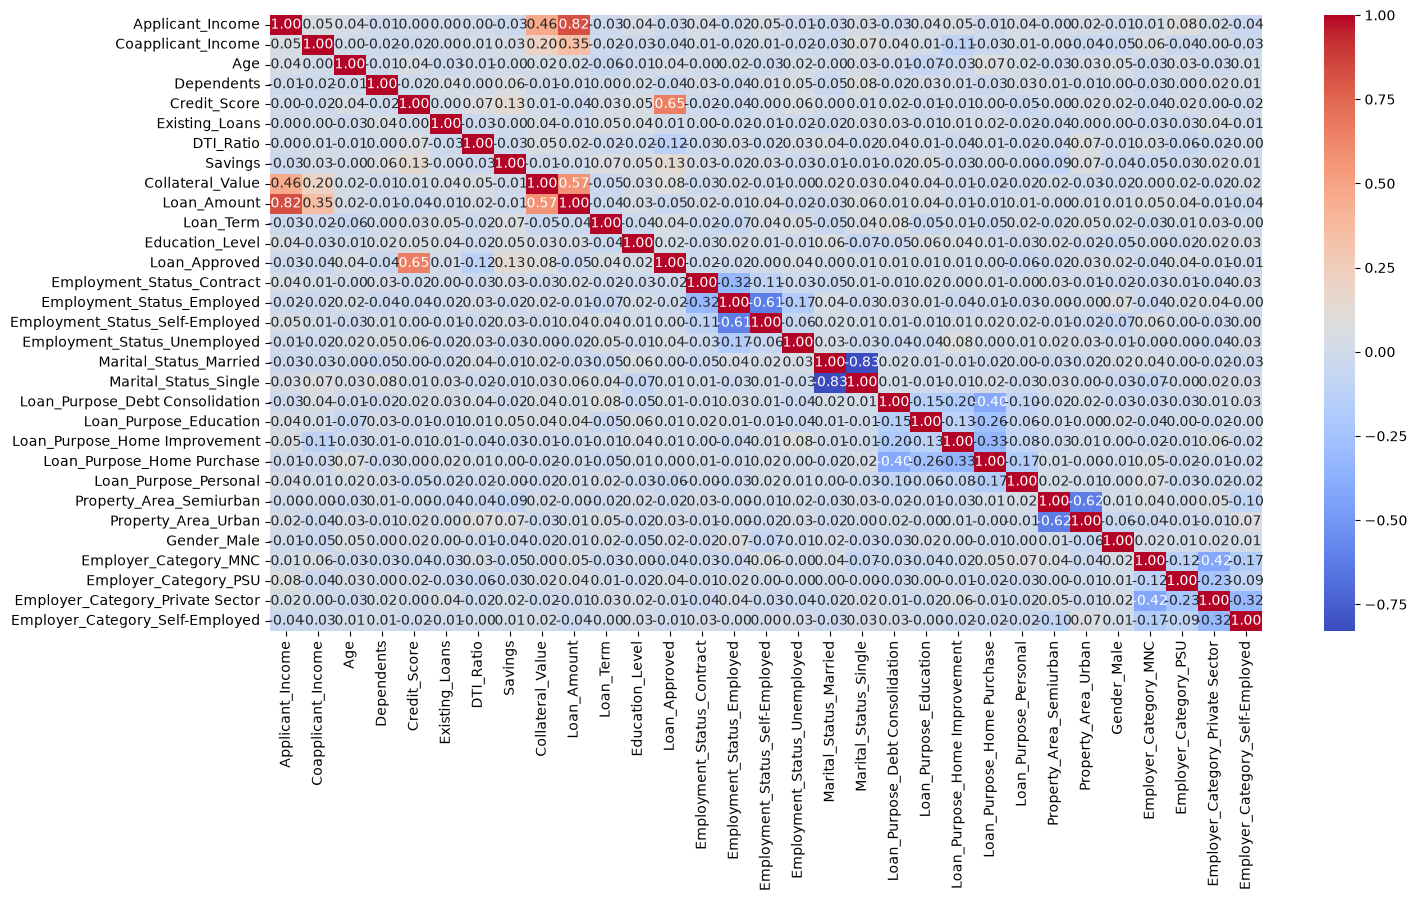

In [46]:
nums_col = df.select_dtypes(include="number")
corr_matrix = nums_col.corr()    

plt.figure(figsize=(16,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

In [38]:
nums_col.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                       1.000000
Credit_Score                        0.652748
Savings                             0.130479
Collateral_Value                    0.082202
Loan_Term                           0.043545
Age                                 0.041300
Employment_Status_Unemployed        0.036860
Employer_Category_PSU               0.035544
Property_Area_Urban                 0.026576
Gender_Male                         0.021050
Education_Level                     0.019592
Loan_Purpose_Debt Consolidation     0.013878
Loan_Purpose_Education              0.009845
Marital_Status_Single               0.007270
Loan_Purpose_Home Improvement       0.006925
Existing_Loans                      0.006201
Marital_Status_Married              0.002756
Loan_Purpose_Home Purchase          0.002727
Employment_Status_Self-Employed     0.001821
Employer_Category_Private Sector   -0.006559
Employer_Category_Self-Employed    -0.009625
Employment_Status_Contract         -0.019343
Property_A

In [50]:
X = df.drop("Loan_Approved",axis=1)
y = df["Loan_Approved"]

In [53]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [54]:
X_test.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Home Improvement,Loan_Purpose_Home Purchase,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_MNC,Employer_Category_PSU,Employer_Category_Private Sector,Employer_Category_Self-Employed
521,50300.0,16500.0,38.0,2.0,719.0,1.0,0.335,16500.0,0.0,106000.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
737,65500.0,15400.0,37.0,0.0,578.0,0.0,0.398,17700.0,403200.0,336000.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
740,12000.0,0.0,30.0,0.0,583.0,1.0,0.288,32400.0,0.0,26000.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
660,25700.0,20900.0,41.0,1.0,715.0,1.0,0.050,60300.0,204000.0,170000.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
411,18500.0,0.0,64.0,2.0,588.0,2.0,0.418,5000.0,0.0,74000.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


In [56]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [57]:
X_train_scaled

array([[-0.46879318, -0.89072056, -1.62221988, ..., -0.25543363,
        -0.90453403,  2.88137564],
       [-0.22876773,  1.12870535,  0.21451914, ...,  3.91491132,
        -0.90453403, -0.34705645],
       [-0.47922907, -0.89072056, -0.8236377 , ..., -0.25543363,
        -0.90453403, -0.34705645],
       ...,
       [-0.10353706, -0.89072056, -0.90349592, ..., -0.25543363,
         1.1055416 , -0.34705645],
       [-0.20789595,  0.09621691,  1.49225063, ..., -0.25543363,
         1.1055416 , -0.34705645],
       [-0.50010084,  0.18731884, -0.50420483, ..., -0.25543363,
        -0.90453403, -0.34705645]], shape=(800, 30))

In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
log_model = LogisticRegression()

log_model.fit(X_train_scaled,y_train)
y_pred = log_model.predict(X_test_scaled)
# Evalution
print("logistic regression model")
print("precision :",precision_score(y_test,y_pred))
print("accuracy score :",accuracy_score(y_test,y_pred))
print("recall score :",recall_score(y_test,y_pred))
print("f1 score :",f1_score(y_test,y_pred))
print("CM :",confusion_matrix(y_test,y_pred))

logistic regression model
precision : 0.873015873015873
accuracy score : 0.855
recall score : 0.8943089430894309
f1 score : 0.8835341365461847
CM : [[ 61  16]
 [ 13 110]]


In [71]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled,y_train)
y_pred = knn_model.predict(X_test_scaled)

print("knn model model")
print("precision :",precision_score(y_test,y_pred))
print("accuracy score :",accuracy_score(y_test,y_pred))
print("recall score :",recall_score(y_test,y_pred))
print("f1 score :",f1_score(y_test,y_pred))
print("CM :",confusion_matrix(y_test,y_pred))


knn model model
precision : 0.696969696969697
accuracy score : 0.645
recall score : 0.7479674796747967
f1 score : 0.7215686274509804
CM : [[37 40]
 [31 92]]


In [72]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
naive_model = GaussianNB()

naive_model.fit(X_train_scaled,y_train)
y_pred = naive_model.predict(X_test_scaled)

print("knn model model")
print("precision :",precision_score(y_test,y_pred))
print("accuracy score :",accuracy_score(y_test,y_pred))
print("recall score :",recall_score(y_test,y_pred))
print("f1 score :",f1_score(y_test,y_pred))
print("CM :",confusion_matrix(y_test,y_pred))

knn model model
precision : 0.8857142857142857
accuracy score : 0.79
recall score : 0.7560975609756098
f1 score : 0.8157894736842105
CM : [[65 12]
 [30 93]]


In [74]:
# add or transform features
df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2

df["Applicant_Income_log"]=np.log1p(df["Applicant_Income"])

X=df.drop(columns=["Loan_Approved","Credit_Score","DTI_Ratio","Applicant_Income"])
y=df["Loan_Approved"]

# Train and teast
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# scalling
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [75]:
X_train.head()

,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,Employment_Status_Contract,...,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_MNC,Employer_Category_PSU,Employer_Category_Private Sector,Employer_Category_Self-Employed,DTI_Ratio_sq,Credit_Score_sq,Applicant_Income_log
29,0.0,22.0,0.0,0.0,3200.0,0.0,124000.0,240.0,3,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.068644,326041.0,10.325515
535,26600.0,45.0,1.0,1.0,50000.0,210000.0,175000.0,240.0,2,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.112225,426409.0,10.529453
695,0.0,32.0,3.0,1.0,5200.0,0.0,120000.0,240.0,1,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.159201,436921.0,10.315630
557,13900.0,56.0,1.0,2.0,5800.0,126400.0,158000.0,240.0,1,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.190096,481636.0,10.239996
836,18800.0,60.0,0.0,1.0,2800.0,0.0,342000.0,120.0,1,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.033856,429025.0,11.430641
